In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import time, sys, os, copy
sys.path.append('../')
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
from utils.constants import *
import numpy as np
import pandas as pd
from tqdm import trange
from itertools import repeat

import torch
from torch.distributions import Categorical
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn import Module
from torch_geometric.utils import is_undirected, contains_self_loops



from scipy.spatial.distance import cdist
import scipy.io as sio
import umap

from tqdm import tqdm, trange
from termcolor import cprint

from utils.GNNTrainer import Trainer
from utils.utils import load_config, diff
from utils.utils import get_labels, remap_to_ordered_ids, tonp
from utils.utils import getLimitsOfContigElements, get_continuous_indices
from utils.graph_conversion import makeGraphDataPoint, convertToGraphs
from utils.losses import CentroidProximityLoss, DispersionLoss, L2_loss, DimensionSimilarityLoss, SelfSimilarityLoss
from utils.synthetic import sort_with_behavioral, scale, minmax, get_background 
from utils.synthetic import linear_track_back_and_forth, gaussian, get_background2 
from utils.synthetic import embed_fwd_rev_seq, embed_one_seq, embed_three_seq
from utils.graph_utils import get_graph_stats, plotWeightedGraph
from utils.plotting import plot_raster, Plot, save_data_for_figure
from utils.utils import get_significants, clusterize, HiddenPrints
from utils.utils import getOutputEmbeddingSimMatrix, Timer



from models.models import WeightedGCN
from models.Kmeans import Kmeans

from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.profile import get_data_size

from scipy.special import softmax
from torch.utils.tensorboard import SummaryWriter

import resource
torch.multiprocessing.set_sharing_strategy('file_system') 
print(torch.multiprocessing.get_sharing_strategy())
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (4096, rlimit[1]))


matplotlib.rcParams.update(load_config('../configs/rcparams.yaml'))

Python version: 3
running non-deterministic
2.4.0+cu121
file_system


In [4]:
# for correct reproducibility, you should get (array([5, 0, 3, 3, 7]), tensor([4, 9, 3, 0, 3]))
np.random.randint(10, size=5), torch.randint(10, size=(5,))

(array([5, 9, 0, 8, 2]), tensor([3, 3, 1, 5, 6]))

In [5]:
# load the parameters from YAML file

params = load_config('../configs/config.yaml')
params.fs = 1/params.dt # sampling rate

In [6]:
# load CA1 data

dat1 = sio.loadmat(f'{params.path_to_data}/position_per_frame.mat')['position_per_frame'].flatten().astype('float')
dat1 = dat1/dat1.max()*96 # make sure the position ranges from 0 to 96 cm (as in the paper)
X = sio.loadmat(f'{params.path_to_data}/neuronal_activity_mat.mat')['neuronal_activity_mat']

params.N = 452
# params.N = 452 // 3
# X = X[:params.N, :]

params.Ts = X.shape[1]

Pruning factor: 0.0
Before spike pruning: 16982 spikes.


100%|██████████| 452/452 [00:02<00:00, 165.59it/s]                                                                                                             


After spike pruning: 16982 spikes.
Pruning factor: 0.0
Before spike pruning: 21516 spikes.


100%|██████████| 452/452 [00:02<00:00, 166.74it/s]                                                                                                             


After spike pruning: 21516 spikes.


(0.0, 6000.0)

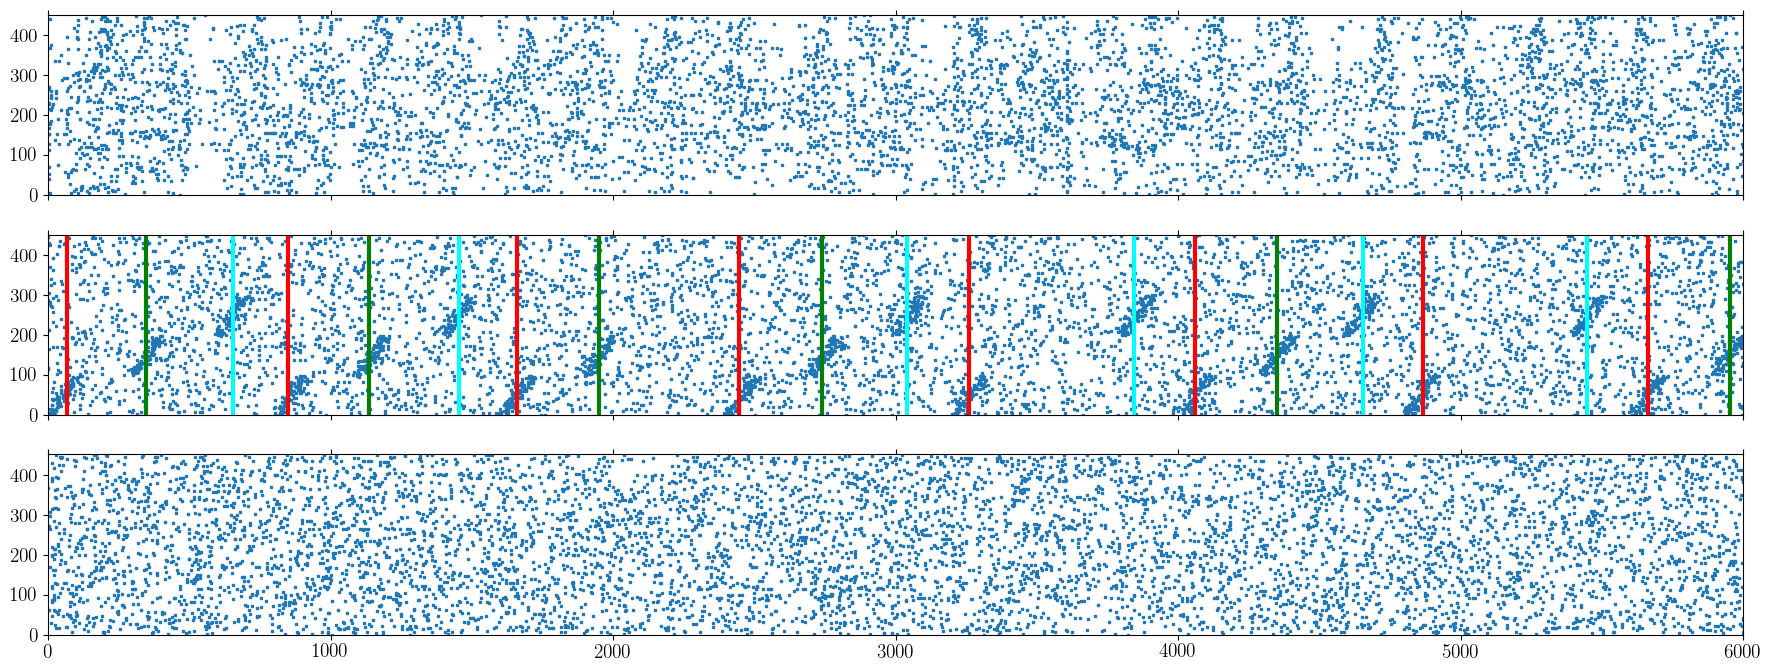

In [55]:
p_drop = 0.2
gap_ts = 800
seqlen = 100
jitter_std = 15

X_ = get_background2(X, pruning_factor=0.0)
X_, GT = embed_three_seq(X_, params, p_drop, gap_ts, seqlen, jitter_std)
Xnull = get_background2(X_, pruning_factor=0.0)


colors = ['red', 'green', 'cyan']
fig, ax = plt.subplots(3, 1, figsize=(18,7), sharex=True)
ax[0].spy(X, aspect='auto', markersize=1.5, origin='lower')
ax[1].spy(X_, aspect='auto', markersize=1.5, origin='lower')
ax[2].spy(Xnull, aspect='auto', markersize=1.5, origin='lower')

for s, c in zip(GT, colors):
    for i in s:
        ax[1].axvline(i, color=c)
        
ax[0].set_xlim(0, 6000)

In [56]:
# convert to graphs 
winsize = 100
step_sz = 4
tau = 25

    
DATA = convertToGraphs(X_, winsize, step_sz, tau, num_workers=20)   
DATAnull = convertToGraphs(Xnull, winsize, step_sz, tau, num_workers=20)

# move data to device
for i in trange(len(DATA), bar_format=bar_format):
    DATA[i] = DATA[i].to(device=params.device)
    
# move data to device
for i in trange(len(DATAnull), bar_format=bar_format):
    DATAnull[i] = DATAnull[i].to(device=params.device)

100%|██████████| 4510/4510 [00:00<00:00, 141608.23it/s]                                                                                                        

dataset_sz_MB: 516.56 | num_datapoints: 4510



100%|██████████| 4510/4510 [00:00<00:00, 141179.14it/s]                                                                                                        


dataset_sz_MB: 488.94 | num_datapoints: 4510


100%|██████████| 4510/4510 [00:00<00:00, 6197.56it/s]                                                                                                          


In [57]:
winsize

100

Text(0.5, 1.0, 'tau=24.04, halflife: 16.667')

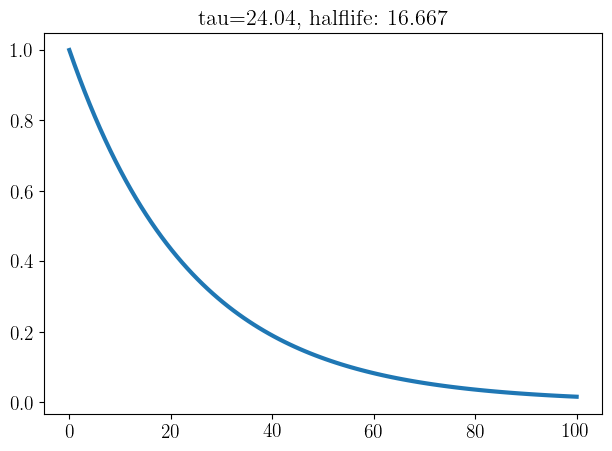

In [58]:
time_gap = np.linspace(0.001, winsize, 100)

halflife = winsize/6
tau = halflife/np.log(2) # samples
exp_wgt = np.exp(-time_gap/tau)

plt.plot(time_gap, exp_wgt)
plt.title(f'tau={tau:.2f}, halflife: {halflife:.3f}')

In [59]:
%autoreload 2

from models.models import WeightedGCN
# from models.Kmeans_new import Kmeans
from models.Kmeans import Kmeans
from utils.GNNTrainer import Trainer

deterministic = False

params.z_dim = 6
params.K = 6

model = WeightedGCN(params).to(params.device)
kmeans = Kmeans(params, debug=False)
writer = SummaryWriter(log_dir='../runs/')
optimizer = optim.AdamW(model.parameters(), lr=0.05) # tell the optimizer which var we want optimized
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.05, total_iters=100)
trainer = Trainer(DATA, X_, model, optimizer, scheduler, kmeans, params, step_sz)

fnames = [i for i in os.listdir("../data/") if i.startswith('proj')]
for fn in fnames:
    os.remove(f"../data/{fn}")

Number of parameters in model: 4622
WeightedGCN(
  (embed): Embedding(452, 10)
  (convs): ModuleList(
    (0): GCNConv(10, 6)
  )
  (activate): Identity()
  (drop): Dropout(p=0.0, inplace=False)
  (readout): Sequential(
    (0): Linear(in_features=6, out_features=6, bias=False)
  )
)


In [60]:
with Timer():
    trainer.MAX_EPOCHS = 400
    trainer.train()

PROXIMITY: -4.64 | VAR: 0.00 | ENTROPY: 0.00 | XENT: 0.19 | DISPERS: 0.00 | L2: 2.29 | TV: 0.43 | JUMPINESS: 0.04 | DIVERSITY: -1.79 | DISPERSION: 21.71 | SELF

127.9999 s.


In [43]:
DATA[2479]

Data(x=[9, 1], edge_index=[2, 30], edge_weight=[30])

In [44]:
DATA[2479].num_nodes, DATA[2479].num_edges

(9, 30)

In [45]:
DATA[2479].x

tensor([[ 20],
        [ 26],
        [144],
        [196],
        [244],
        [317],
        [396],
        [421],
        [437]], device='cuda:0')

In [46]:
DATA[1100].edge_index

tensor([[ 1,  2,  4,  5,  6,  7,  8, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22,
         23, 25, 26,  2,  4,  5,  6,  7,  8, 13, 15, 16, 17, 18, 22, 25, 26,  4,
          5,  7,  8, 13, 15, 16, 18, 22, 25, 26,  0,  1,  2,  4,  5,  6,  7,  8,
         10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,  5,
          8, 13, 15, 18, 22, 25,  8, 13, 15, 18, 22, 25,  4,  5,  7,  8, 13, 15,
         16, 18, 22, 25, 26,  1,  2,  4,  5,  6,  8, 13, 15, 16, 17, 18, 22, 25,
         26, 22,  0,  1,  2,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26,  0,  1,  2,  4,  5,  6,  7,  8, 11,
         12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26,  1,  2,  4,  5,  6,
          7,  8, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 25, 26,  1,  2,  4,  5,
          6,  7,  8, 13, 15, 16, 17, 18, 22, 25, 26,  8, 22,  0,  1,  2,  4,  5,
          6,  7,  8, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26,  8,
         13, 22,  4,  5,  8,

In [47]:
DATA[2479].edge_weight

tensor([1.7973, 1.7973, 1.7973, 1.7973, 0.7261, 0.7558, 0.5273, 1.7268, 0.9608,
        1.7268, 1.7268, 1.7268, 0.6977, 0.7261, 0.5066, 2.4751, 2.4751, 2.4751,
        2.4751, 0.7261, 2.3781, 2.3781, 2.3781, 2.3781, 0.9608, 0.6977, 3.4086,
        3.4086, 3.4086, 3.4086], device='cuda:0')

In [48]:
# np.argmin([i.num_nodes for i in DATA])
    

$$
\mathcal V = \{9,5,4,7,1 \}
\\
\mathcal E = \{(9,5), (9,4), (9,7), (9,1), (5,4), (5,7), (5,1), (4,1), (4,7), (7,8) \}
$$

$$
\mathcal W = \{0.961, 0.852, 0.787, 0.756, 0.887, 0.819, 0.787, 0.887, 0.923, 0.961 \}
$$

In [50]:
np.round(np.exp(-np.array([1,4,6,7,3,5,6,3,2,1])/25), 3)

array([0.961, 0.852, 0.787, 0.756, 0.887, 0.819, 0.787, 0.887, 0.923,
       0.961])

Use matcha
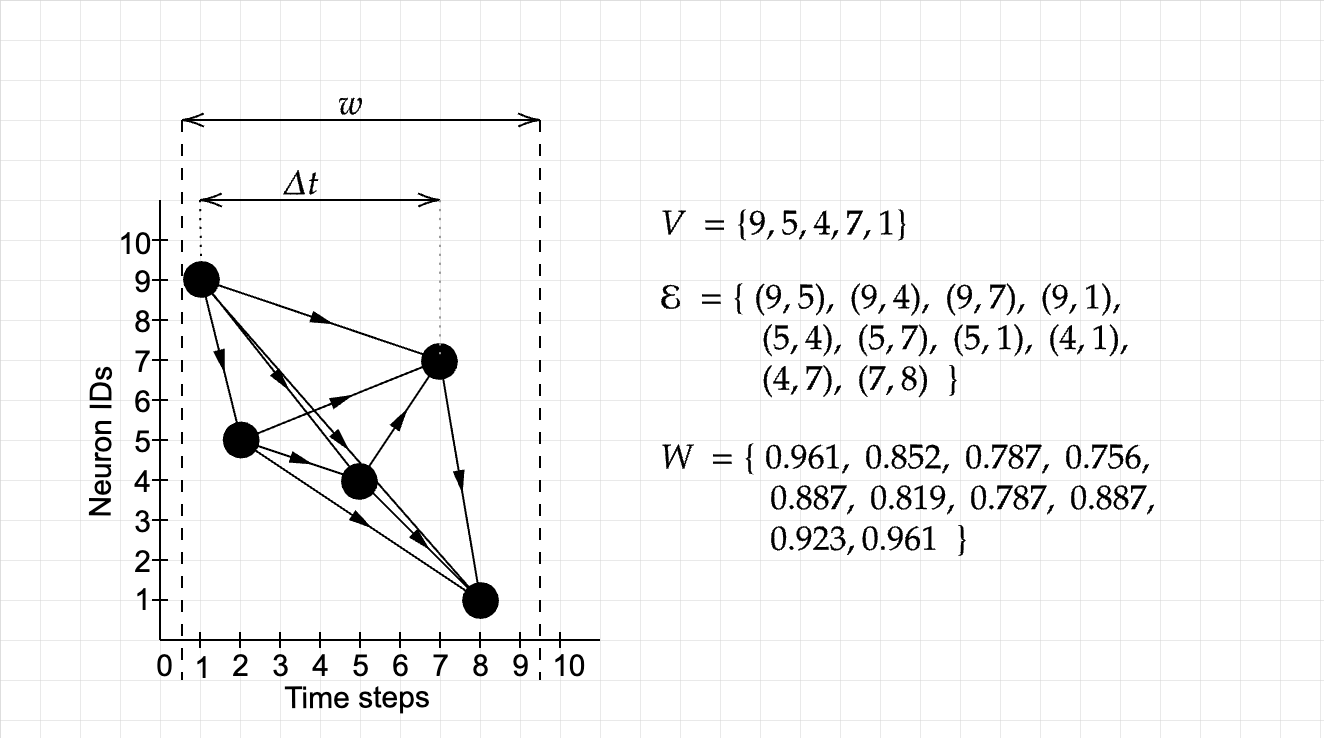